In [16]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [17]:
pokemon_df = pd.read_csv('C:/Users/Carlos/Documents/DarkDex/darkdex/archives/Pokemon.csv')

In [18]:
pokemon_df = pokemon_df.rename(
    columns={
        "#": "id",
        "Name": "name",
        "Attack": "attack",
        "Defense": "defense",
        "Sp. Atk": "sp_attack",
        "Sp. Def": "sp_defense",
        "HP": "hp",
        "Speed": "speed",
    }
)

In [19]:
pokemon_df["offensive_power"] = pokemon_df["attack"] + pokemon_df["sp_attack"]
pokemon_df["defensive_power"] = pokemon_df["defense"] + pokemon_df["sp_defense"]
pokemon_df["bulk"] = pokemon_df["hp"] + pokemon_df["defensive_power"]
pokemon_df["speed_score"] = pokemon_df["speed"]

In [20]:
counts_df = pokemon_df.groupby('id').size().reset_index(name='Total_Count')

In [21]:
pokemon_df = pokemon_df[
    ~pokemon_df["name"].str.contains(
        "Primal|Gigantamax|Ultra|Gmax|Alolan|Galarian|Hisuian|Mega|Shadow|Origin|Totem|Therian|Eternamax|Rotom|Forme",
        case=False,
        na=False,
    )
]

In [22]:
def plot_distribution(df, identificacao, x, y=None, z=None, color=None, jitter_1d=0.02):

    df = df.copy()

    if z is not None and y is not None:
        fig = px.scatter_3d(
            df,
            x=x,
            y=y,
            z=z,
            color=color,
            opacity=0.8,
            hover_name=identificacao,
            title="Visualização 3D Interativa"
        )

    elif y is not None:
        fig = px.scatter(
            df,
            x=x,
            y=y,
            color=color,
            opacity=0.8,
            hover_name=identificacao,
            title="Visualização 2D Interativa"
        )

    else:
        df["_y_dummy"] = np.random.uniform(
            low=-jitter_1d,
            high=jitter_1d,
            size=len(df)
        )

        fig = px.scatter(
            df,
            x=x,
            y="_y_dummy",
            color=color,
            opacity=0.8,
            hover_name=identificacao,
            title="Visualização 1D Interativa"
        )

        fig.update_yaxes(visible=False)

    fig.update_traces(marker=dict(size=7))
    fig.update_layout(
        width=900,
        height=600,
        legend_title=color
    )

    fig.show()

In [23]:
plot_distribution(pokemon_df, 'name', 'offensive_power')

In [24]:
def definir_clusters_cotovelo(df_kmeans, columns):
    scaler = StandardScaler()

    df_scaled = scaler.fit_transform(df_kmeans[columns])

    inertia = []
    for n_clusters in range(1, 11):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(df_scaled)
        inertia.append(kmeans.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 11), inertia, marker='o')
    plt.xlabel('Número de Clusters')
    plt.ylabel('Inércia')
    plt.title('Método do Cotovelo com RobustScaler')
    plt.show()

    return df_kmeans, df_scaled

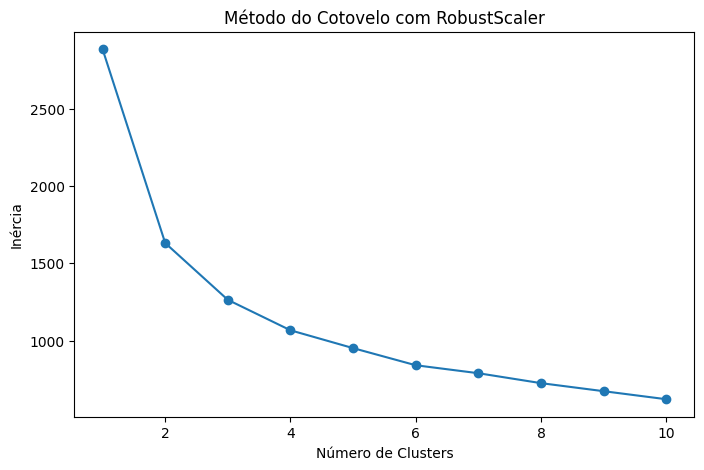

In [25]:
df_kmeans_1 = pokemon_df.copy()
columns_1 = ["offensive_power", "defensive_power", "bulk", "speed_score"]
df_kmeans_1, df_scaled_1 = definir_clusters_cotovelo(df_kmeans_1, columns_1)

In [26]:
import pickle

def run_kmeans(df_kmeans, df_scaled, n_clusters=3, percentile_threshold=95):
    n_clusters = n_clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(df_scaled)

    centroids = kmeans.cluster_centers_
    df_kmeans['cluster'] = clusters

    distances = np.linalg.norm(df_scaled - centroids[clusters], axis=1)
    threshold_distance = np.percentile(distances, percentile_threshold)

    df_kmeans['distance'] = distances
    df_kmeans['outlier'] = df_kmeans['distance'] > threshold_distance

    with open('kmeans_pokemon.pkl', 'wb') as f:
        pickle.dump(kmeans, f)

    return df_kmeans, centroids

In [27]:
outliers_df_1, centroids_1 = run_kmeans(df_kmeans_1, df_scaled_1, n_clusters=4)

In [29]:
plot_distribution(df_kmeans_1, "name", "offensive_power", "defensive_power", "bulk", color="cluster")

In [30]:
plot_distribution(df_kmeans_1, "name", "offensive_power", "defensive_power", "speed_score", color="cluster")